## Lecture 6: Distributed Computing 1

### ****Milestone 1:** Dask Mandelbrot (local)**

****Approach:** wrap your existing `Numba_mandelbrot_chunk` with `dask.delayed` — same row-chunk structure as L04/L05, one task per row-band:**

`dask.compute(*[delayed(f)(args) for args in chunk args])` ← replaces `pool.map(f, chunk args)`

****Common pitfall:** Do NOT iterate Dask arrays inside the `max_iter` loop (e.g. `Z = da.where(...)`). Each of the 100 iterations becomes a separate task — $∼100,000$ tasks for $N = 1024$ — and overhead dominates. `dask.delayed` wraps the entire Numba function as *one* atomic task per chunk.**

In [15]:
# A copy from lecture 5

from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [16]:
# From slide 34

from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics
# mandelbrot_chunk: your @njit(cache=True) function from L04/L05
def mandelbrot_dask(N, x_min, x_max, y_min, y_max,
                    max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(
            row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

if __name__ == '__main__':
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
    cluster = LocalCluster(n_workers=8, threads_per_worker=1)
    client = Client(cluster)
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX, # warm up all workers
                                        Y_MIN, Y_MAX, 10))
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        result = mandelbrot_dask(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)
    print(f"Dask local (n_chunks=32): {statistics.median(times):.3f} s")
    client.close(); cluster.close()

Dask local (n_chunks=32): 0.062 s


**1. Implement `mandelbrot_dask()` using `dask.delayed` (see code example).**

Done. Please see the code above.

**2. Verify: `np.array_equal(ref, result)` against your serial output.**

In [17]:
# Serial
ref = mandelbrot_chunk(0, N, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)

assert np.array_equal(ref, result)

**3. Warm up Numba JIT in *all* workers with `client.run()` before timing.**

Done. Please see the main code block above.

**4. Time 3 runs; record `statistics.median()`.**

Done.

****Done?** Record time in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 52996111e6d3f507b4df00e0c2e4b6d3658df8f1 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Tue Mar 24 19:39:35 2026 +0000

    l06: milestone 1 done
```

### ****Milestone 2:** Chunk size sweep**

**Find the optimal chunk count for Dask local on your machine.**

****Sweep** `n_chunks` over a range guided by the three-way trade-off (see theory slides). For each setting: time 3 runs (median), compute $LIF = p \cdot T_p / T_1 − 1$.**

**1. Adapt your L05 Dask implementation to loop over `n_chunks` values: keep `LocalCluster` open across all measurements (start-up cost paid once).**

*Note:* We did not work with Dask in lecture five. I am unsure why this exercise thinks so.

In [18]:
def compute_ms1():
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
    cluster = LocalCluster(n_workers=8, threads_per_worker=1)
    client = Client(cluster)
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX,  # warm up all workers
                                        Y_MIN, Y_MAX, 10))

    n_chunks_arr = [1, 2, 4, 8, 16, 32]
    times_res = []
    lifs = []
    vs1x = []
    speedups = []

    for n_chunks in n_chunks_arr:
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            result = mandelbrot_dask(
                N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
            times.append(time.perf_counter() - t0)

        T_p = statistics.median(times)
        times_res.append(T_p)
        T_1 = times_res[0]
        vs1x.append(T_p / T_1)
        speedups.append(T_1 / T_p)
        lifs.append(8 * T_p / T_1 - 1)

    client.close()
    cluster.close()

    return n_chunks_arr, times_res, vs1x, speedups, lifs

In [19]:
from pathlib import Path
import pandas as pd

ms1_file = Path("l06_milestone1.csv")

if not ms1_file.exists():
    n_chunks, times, vs1x, speedups, lifs = compute_ms1()
    df = pd.DataFrame({
        "n_chunks": n_chunks,
        "time": times,
        "vs1x": vs1x,
        "speedup": speedups,
        "lif": lifs
    })
    df.to_csv(ms1_file, index_label=False)

**2. Warm up Numba JIT in *all* workers with `client.run()` before the sweep loop.**

Done! Please see the code above.

**3. Record: wall time and LIF per `n_chunks`; plot wall time vs. n_chunks (log scale).**

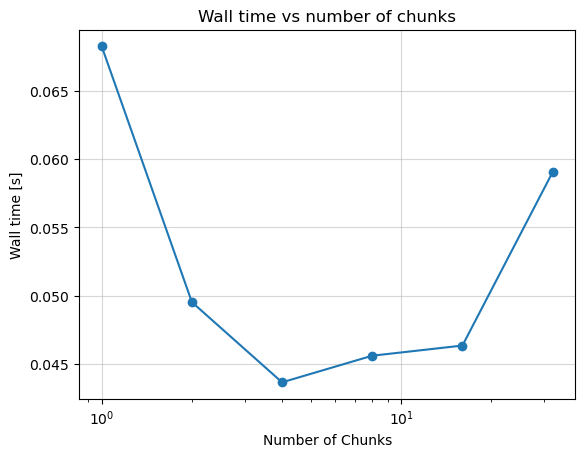

In [20]:
import matplotlib.pyplot as plt


ms1_results = pd.read_csv(ms1_file)

wall_time = ms1_results["time"]
n_chunks = ms1_results["n_chunks"]

plt.plot(n_chunks, wall_time, marker="o")
plt.xscale("log")
plt.xlabel("Number of Chunks")
plt.ylabel("Wall time [s]")
plt.grid(alpha=0.5)
plt.title("Wall time vs number of chunks")
plt.savefig("dask_chunk_sweep.png")
plt.show()


**4. Note: Dask has higher $\alpha$ per task than multiprocessing — expect the optimal `n_chunks` to be smaller than in L05.**

Sure..... Noted.

****Print table columns:****

**`n_chunks | time (s) | vs 1x | speedup | LIF`**

In [21]:
from IPython.display import Markdown, display

df_display = ms1_results.copy()
df_display["n_chunks"] = df_display["n_chunks"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["vs1x"] = df_display["vs1x"].map("{:>.2f}x".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["lif"] = df_display["lif"].map("{:>.2f}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   n_chunks | time   | vs1x   | speedup   |   lif |
|-----------:|:-------|:-------|:----------|------:|
|          1 | 0.068s | 1.00x  | 1.00x     |  7    |
|          2 | 0.050s | 0.73x  | 1.38x     |  4.81 |
|          4 | 0.044s | 0.64x  | 1.56x     |  4.12 |
|          8 | 0.046s | 0.67x  | 1.50x     |  4.35 |
|         16 | 0.046s | 0.68x  | 1.47x     |  4.43 |
|         32 | 0.059s | 0.87x  | 1.16x     |  5.92 |

****Record:****

**`n_chunks_optimal, t_min, LIF_min`**

**Save plot as `dask_chunk_sweep.png`**

In [22]:
row_idx = ms1_results["time"].idxmin()

n_chunks_optimal = int(ms1_results.iloc[row_idx]["n_chunks"])
t_min = float(ms1_results.iloc[row_idx]["time"])
LIF_min = float(ms1_results.iloc[row_idx]["lif"])

print(f"{n_chunks_optimal=}")
print(f"{t_min=:.3f}s")
print(f"{LIF_min=:.2f}")

n_chunks_optimal=4
t_min=0.044s
LIF_min=4.12


****Optional:** Add block-level early exit to your Numba kernel: after each iteration step, check if all pixels in the chunk have diverged — if so, break the loop. Chunks entirely outside the Mandelbrot set then skip remaining iterations. Compare timing with and without this optimisation.**

In [23]:
from numba import njit
import numpy as np

@njit(cache=True)
def mandelbrot_chunk_early(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.zeros((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N

    z_real = np.zeros_like(out)
    z_imag = np.zeros_like(out)
    alive = np.ones_like(out)
    escaped = np.zeros_like(out, dtype=np.bool_)

    # Mach forward per iterations
    for i in range(max_iter):

        # EXIT if all chunks are done (EXTREMELY UNLIKELY)
        if not np.any(alive):
            break

        # For each chunk
        for row in range(row_end - row_start):

            # EARLY EXIT CHUNK
            if not np.any(alive[row, :]):
                continue

            c_imag = y_min + (row + row_start) * dy

            # For each pixel in chunk
            for col in range(N):

                # mandelbrot pixel
                zr2 = z_real[row, col] * z_real[row, col]
                zi2 = z_imag[row, col] * z_imag[row, col]
                if zr2 + zi2 > 4.0:
                    if not out[row, col]:
                        out[row, col] = i
                        escaped[row, col] = True
                    alive[row, col] = 0 # Keep nagging the chunk. We are dead

                # The "expense" of not escaping pixel wise
                z_imag[row, col] = 2.0*z_real[row, col]*z_imag[row, col] + c_imag
                z_real[row, col] = zr2 - zi2 + x_min + col*dx

    # I wished numba supported binary masks :(
    # out[escaped != True ] = max_tier
    for row in range(row_end - row_start):
        for col in range(N):
            if not escaped[row, col]:
                out[row, col] = max_iter
    
    return out

*Note:* that we must change the following:
- $z$ must now be stored per pixel. Comparing to before, it was local function scoped within `mandelbrot_pixel()`
- We must also now keep track of which pixels in a chunk are done, in order to determine if we totally done image wise.
- Some points never reach `max_iter` and some points exit *very* early, both cases result in its pixel value staying at $0$. To separate them, a binary mask is used.

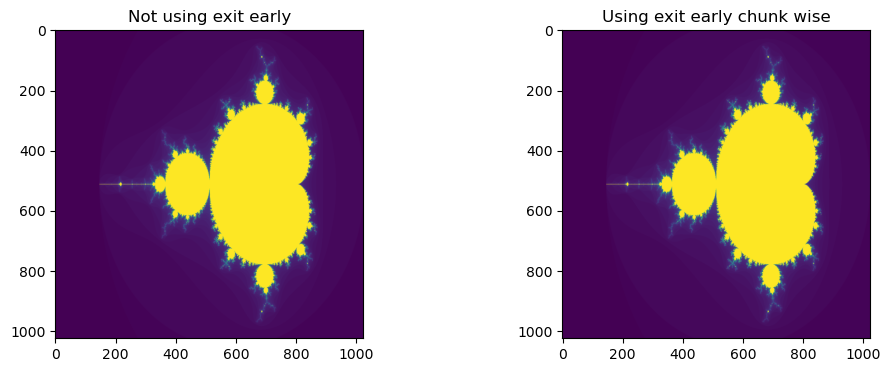

In [24]:
image_normal = mandelbrot_chunk(0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, max_iter=100)
image_early = mandelbrot_chunk_early(0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, max_iter=100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image_normal)
axes[0].set_title("Not using exit early")
axes[1].imshow(image_early)
axes[1].set_title("Using exit early chunk wise")
plt.show()

assert np.array_equal(image_normal, image_early)

Lets also time them.

In [25]:
def benchmark(func: callable, args):
    func(*args)  # warm up

    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = func(*args)
        times.append(time.perf_counter() - t0)

    return statistics.median(times)


time_normal = benchmark(
    mandelbrot_chunk, (0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, 100)
)
time_early = benchmark(
    mandelbrot_chunk_early, (0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, 100)
)

print(f"NOT using early stop:\t{time_normal:.3f}s")
print(f"Using early stop:\t{time_early:.3f}s")

NOT using early stop:	0.069s
Using early stop:	0.215s


I suspect that the slowdown is due to more active memory access patterns and that we are using about $4\times$ as much (global) memory.

****Done?** Record `n_chunks` optimal and `LIF_min` in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 2afef423b93a5df80b973ea512823fec74814000 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Mar 25 21:32:19 2026 +0000

    l06: milestone 2 done
```

### ****Milestone 3:** Full benchmark (all methods)**

**Collect all timings and compare every implementation built so far.**

**Add a Dask row to your performance notebook:**

| **Implementation**      | **Time (s)**        | **Speedup vs. naive** |
| ----------------------- | ------------------- | --------------------- |
| Naive Python            |                     | 1×                    |
| NumPy                   |                     |                       |
| Numba (@njit)           |                     |                       |
| Numba + multiprocessing |                     |                       |
| Dask local              |                     |                       |
| Dask cluster            | (to be added in L7) |                       |


Here is my table:

| **Implementation**      | **Time (s)**        | **Speedup vs. naive** |
| ----------------------- | ------------------- | --------------------- |
| Naive Python            | 4.113s              | 1×                    |
| NumPy                   | 0.578s              | 6.85x                 |
| Numba (@njit)           | 0.048s              | 86.6x                 |
| Numba + multiprocessing | 0.269s              | 15.3X                 |
| Dask local              | 0.044s              | 93.4x                 |
| Dask cluster            | -                   | -                     |

**Reflection questions (address in your written reflection):**

- **How does Dask local compare to multiprocessing at the same worker count?**

Using "Dask local" is $\frac{0.269 \text{s}}{0.044 \text{s}} = 6.11\times$ faster than using "Numba + multiprocessing" both using the same number of cores. I suspect that "Numba + multiprocessing" is slower since we must use the Pythons `Pool.map()`. Perhaps Dask IPC is more efficient and faster than Python.

- **What does the overhead difference tell you about when to choose each tool?**

I would chose my tools in the following order:

1. *Numba (@njit):* Compiled machine code is often about $~100\times$ faster than Python. Combing both Python and machine code is very easy to do with Numba, but it does not work in some scenarios.
2. *Dask Local (with Numba):* Scaling compiled Python code with Dask is easy to program, also helping with scaling to hounders of computers.

The other options are not very performant. It is always a trade-off between easy of implementation and platform integration (Python vs C vs CUDA for example). 

****Submit:** Add your Dask local result to the Performance Tracker in Moodle.**

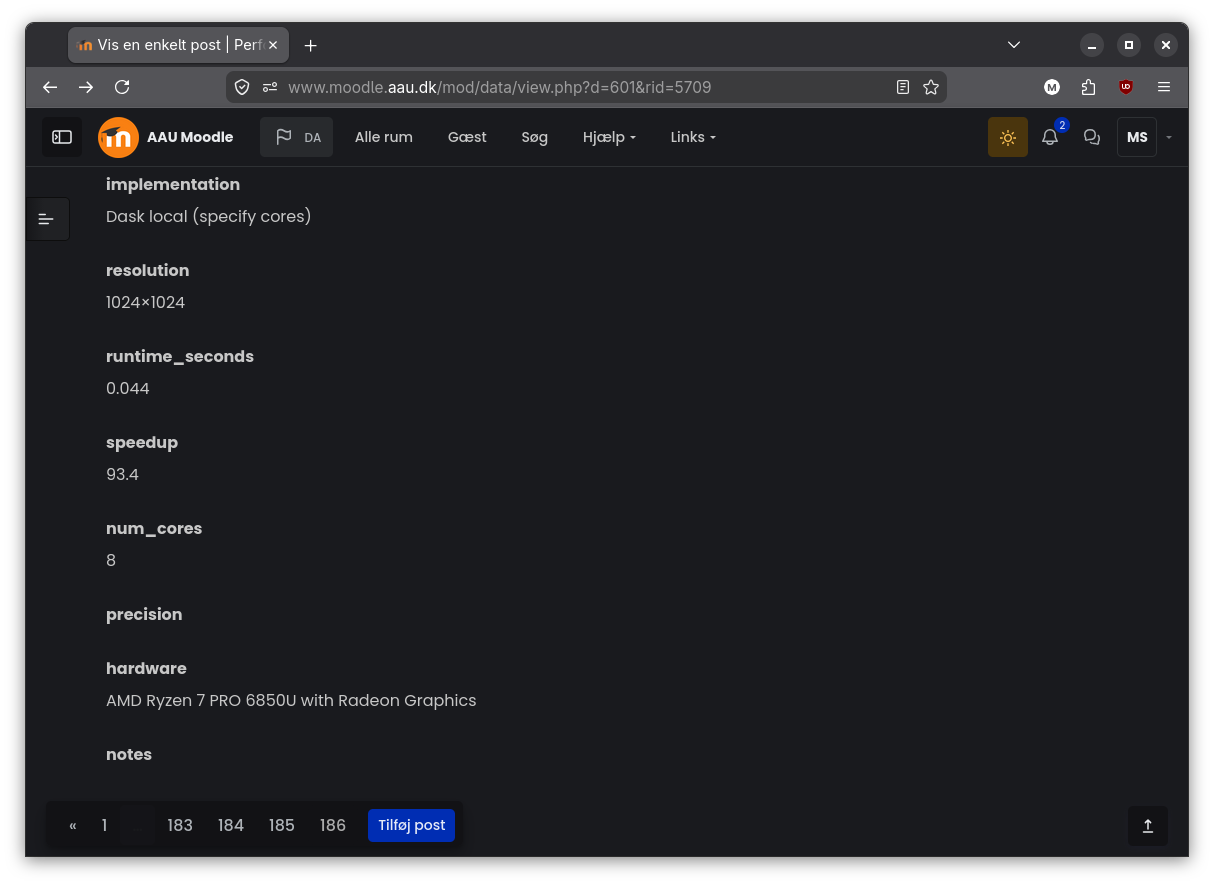

****Done?** Record all results in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit e7ba37c5b3ff0188601e18035a7c1cea72d651b9 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Mar 25 22:02:30 2026 +0000

    l06: milestone 3 done
```